In [3]:
# # Install CellSAM
# # !pip install git+https://github.com/vanvalenlab/cellSAM.git
# # Alternative installation with all dependencies
# !pip install torch torchvision  # Make sure PyTorch is installed first
# !pip install git+https://github.com/vanvalenlab/cellSAM.git

In [4]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Specify GPU 0 (out of 4 available GPUs)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))
print(f"✅ Working directory: {os.getcwd()}")
print(f"✅ Using GPU: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest
✅ Using GPU: 0


In [5]:
# Step 1: Check what's available in cellSAM
import cellSAM
print("Available functions in cellSAM:")
print(dir(cellSAM))

Available functions in cellSAM:
['AnchorDETR', 'CellSAM', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_auth', 'cellsam_pipeline', 'download_training_data', 'get_local_model', 'get_model', 'model', 'sam_inference', 'segment_cellular_image', 'utils', 'wsi']



--- STEP 1: Running cellSAM on mIF (Reference) ---
✓ cellSAM Reference generated (174 cells)

--- STEP 2: Reconstructing Vitamin-P Mask from GeoJSON ---
✓ Vitamin-P Mask reconstructed from 132 polygons

--- STEP 4: Generating Visualization ---


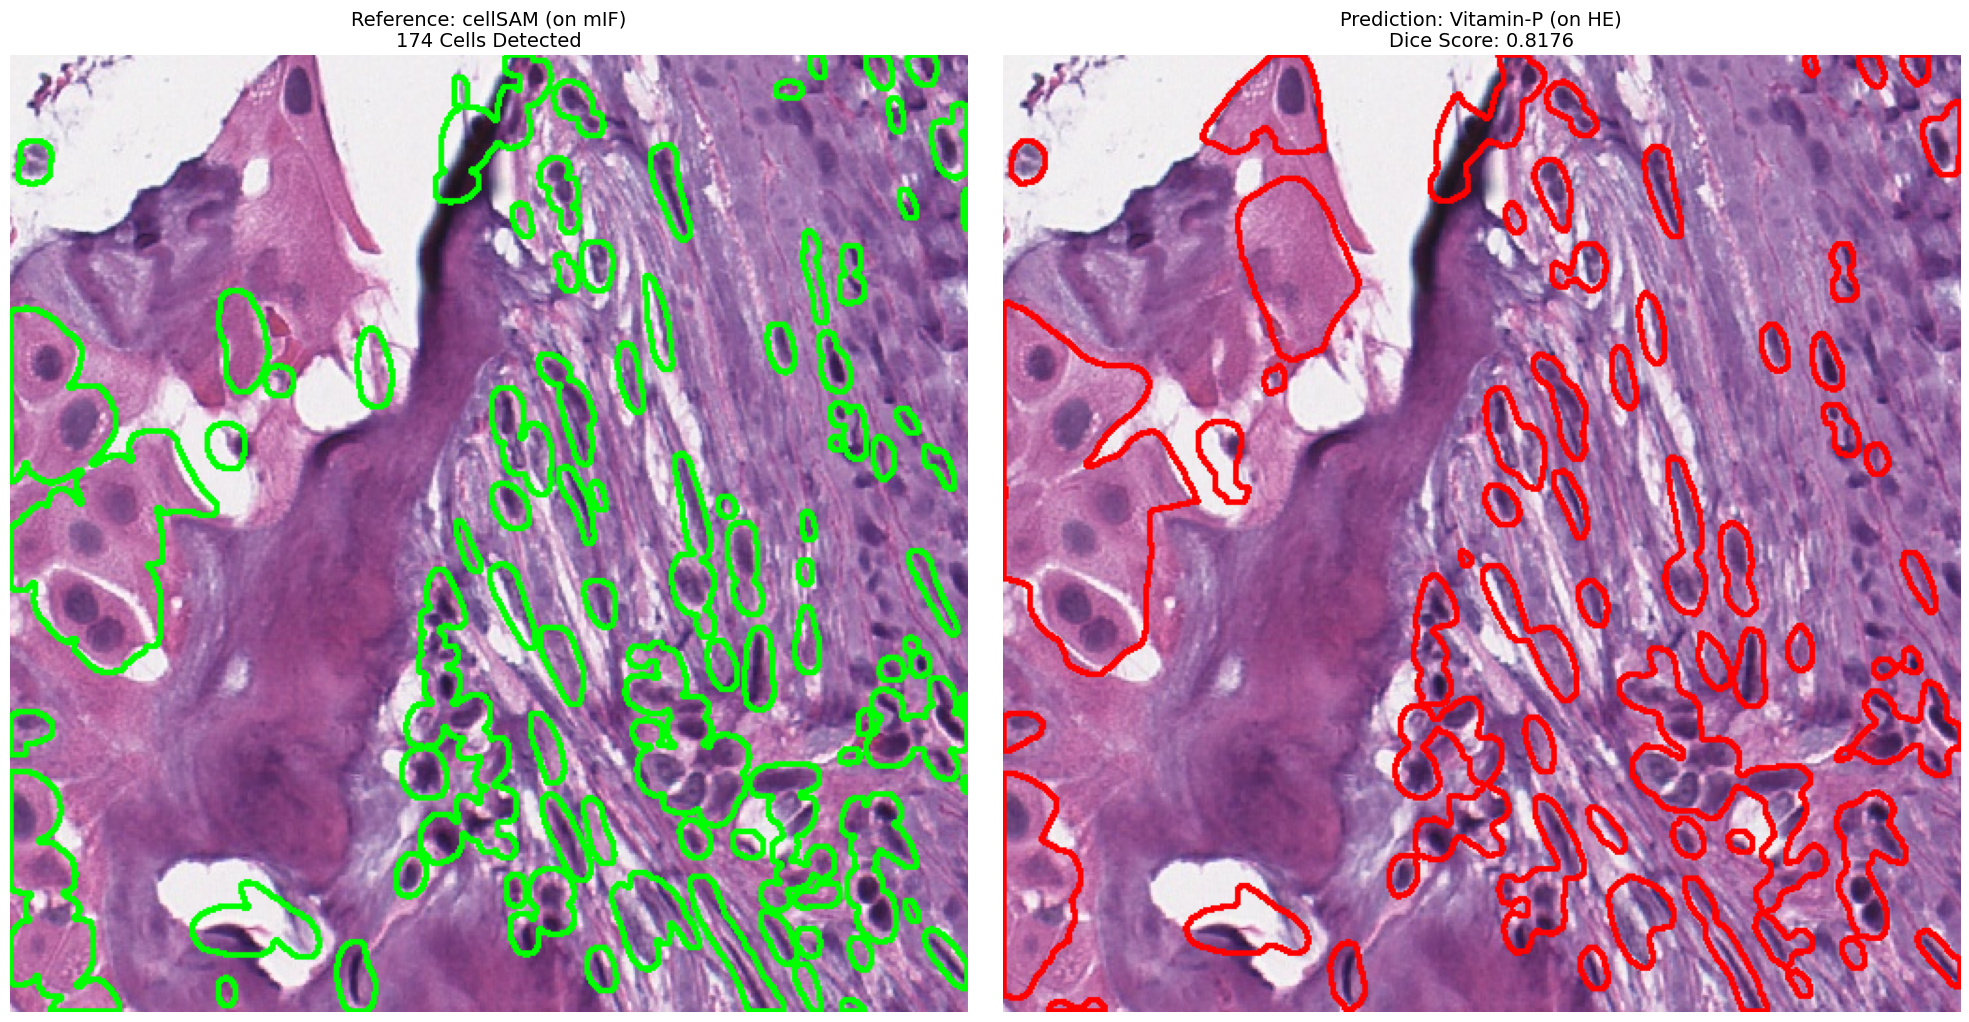


📊 DICE SCORE COMPARISON
Sample          : MOS033
DICE SCORE      : 0.8176


In [7]:
import numpy as np
import cv2
import json
import os
import matplotlib.pyplot as plt
from cellSAM import cellsam_pipeline

# Set DeepCell Token
os.environ['DEEPCELL_ACCESS_TOKEN'] = 'JbVVUStF.A6Ec6pe5vKsoB3RhTnSOaqXJ1thDE3B6'

# ============================================================================
# CONFIGURATION & PATHS
# ============================================================================
HE_PATH  = '/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk/MOS033/MOS033S1_box1n_HE_crop.png'
MIF_PATH = '/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk/MOS033/MOS033S1_box1n_mIF_crop.png'
VITAMINP_GEOJSON = 'predictions_batch_results/MOS033/HE/MOS033_HE_cell.json'

# ============================================================================
# 1. GENERATE REFERENCE WITH CELLSAM (ON MIF)
# ============================================================================
print("\n--- STEP 1: Running cellSAM on mIF (Reference) ---")
mif_raw = cv2.imread(MIF_PATH, cv2.IMREAD_UNCHANGED)
H, W = mif_raw.shape[:2]

def normalize_to_8bit(ch):
    if ch.max() > ch.min():
        ch = (ch - ch.min()) / (ch.max() - ch.min())
    return (ch * 255).astype(np.uint8)

nuc_norm = normalize_to_8bit(mif_raw[:, :, 0])
cell_norm = normalize_to_8bit((mif_raw[:, :, 1].astype(float) + mif_raw[:, :, 2].astype(float)) / 2.0)

sam_input = np.zeros((H, W, 3), dtype=np.uint8)
sam_input[..., 1] = nuc_norm   
sam_input[..., 2] = cell_norm  

pred_cell_sam = cellsam_pipeline(sam_input, use_wsi=False)
mask_ref_sam = (pred_cell_sam > 0).astype(np.uint8)
print(f"✓ cellSAM Reference generated ({len(np.unique(pred_cell_sam))-1} cells)")

# ============================================================================
# 2. RECONSTRUCT VITAMIN-P MASK FROM GEOJSON
# ============================================================================
print("\n--- STEP 2: Reconstructing Vitamin-P Mask from GeoJSON ---")
mask_vit_p = np.zeros((H, W), dtype=np.uint8)

with open(VITAMINP_GEOJSON, 'r') as f:
    data = json.load(f)

for feature in data['features']:
    coords = np.array(feature['geometry']['coordinates'][0], dtype=np.int32)
    cv2.fillPoly(mask_vit_p, [coords], 1)

print(f"✓ Vitamin-P Mask reconstructed from {len(data['features'])} polygons")

# ============================================================================
# 3. CALCULATE DICE SCORE
# ============================================================================
def calculate_dice(mask1, mask2):
    intersection = np.sum((mask1 == 1) & (mask2 == 1))
    sum_masks = np.sum(mask1) + np.sum(mask2)
    if sum_masks == 0: return 1.0
    return (2. * intersection) / sum_masks

dice_score = calculate_dice(mask_ref_sam, mask_vit_p)

# ============================================================================
# 4. VISUALIZATION
# ============================================================================
print("\n--- STEP 4: Generating Visualization ---")
img_he = cv2.cvtColor(cv2.imread(HE_PATH), cv2.COLOR_BGR2RGB)

def create_overlay(img, mask, color=(0, 255, 0)):
    # Create a copy and draw contours
    overlay = img.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, color, 2)
    return overlay

# Create overlays
overlay_sam = create_overlay(img_he, mask_ref_sam, color=(0, 255, 0))   # Green = cellSAM (mIF)
overlay_vit = create_overlay(img_he, mask_vit_p, color=(255, 0, 0))     # Red = Vitamin-P (HE)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(overlay_sam)
axes[0].set_title(f"Reference: cellSAM (on mIF)\n{len(np.unique(pred_cell_sam))-1} Cells Detected", fontsize=14)
axes[0].axis('off')

axes[1].imshow(overlay_vit)
axes[1].set_title(f"Prediction: Vitamin-P (on HE)\nDice Score: {dice_score:.4f}", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"📊 DICE SCORE COMPARISON")
print("="*60)
print(f"Sample          : MOS033")
print(f"DICE SCORE      : {dice_score:.4f}")
print("="*60)

In [8]:
import numpy as np
import cv2
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from cellSAM import cellsam_pipeline

# Set DeepCell Token
os.environ['DEEPCELL_ACCESS_TOKEN'] = 'JbVVUStF.A6Ec6pe5vKsoB3RhTnSOaqXJ1thDE3B6'

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_INPUT_DIR = '/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk'
GEOJSON_ROOT   = 'predictions_batch_results'
PLOT_OUTPUT_DIR = 'dice_comparison_plots'
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

# ============================================================================
# HELPERS
# ============================================================================
def normalize_to_8bit(ch):
    if ch.max() > ch.min():
        ch = (ch - ch.min()) / (ch.max() - ch.min())
    return (ch * 255).astype(np.uint8)

def calculate_dice(mask1, mask2):
    intersection = np.sum((mask1 == 1) & (mask2 == 1))
    sum_masks = np.sum(mask1) + np.sum(mask2)
    if sum_masks == 0: return 1.0
    return (2. * intersection) / sum_masks

# ============================================================================
# BATCH PROCESSING LOOP
# ============================================================================
root_path = Path(BASE_INPUT_DIR)
case_dirs = sorted([d for d in root_path.iterdir() if d.is_dir()])

all_dice_scores = []
results_log = []

print(f"🚀 Starting Batch Evaluation for {len(case_dirs)} cases...\n")

for case_path in case_dirs:
    case_id = case_path.name
    
    # 1. Path Setup
    mif_path = next(case_path.glob("*_mIF_crop.png"), None)
    he_path  = next(case_path.glob("*_HE_crop.png"), None)
    geojson_path = os.path.join(GEOJSON_ROOT, case_id, "HE", f"{case_id}_HE_cell.json")
    
    if not (mif_path and os.path.exists(geojson_path)):
        print(f"⚠️ Skipping {case_id}: Missing mIF or GeoJSON.")
        continue

    try:
        # 2. Run cellSAM on mIF (Reference)
        mif_raw = cv2.imread(str(mif_path), cv2.IMREAD_UNCHANGED)
        H, W = mif_raw.shape[:2]
        
        nuc_norm = normalize_to_8bit(mif_raw[:, :, 0])
        cell_norm = normalize_to_8bit((mif_raw[:, :, 1].astype(float) + mif_raw[:, :, 2].astype(float)) / 2.0)
        
        sam_input = np.zeros((H, W, 3), dtype=np.uint8)
        sam_input[..., 1] = nuc_norm   
        sam_input[..., 2] = cell_norm  
        
        pred_cell_sam = cellsam_pipeline(sam_input, use_wsi=False)
        mask_ref_sam = (pred_cell_sam > 0).astype(np.uint8)

        # 3. Reconstruct Vitamin-P Mask from GeoJSON
        mask_vit_p = np.zeros((H, W), dtype=np.uint8)
        with open(geojson_path, 'r') as f:
            data = json.load(f)
        for feature in data['features']:
            coords = np.array(feature['geometry']['coordinates'][0], dtype=np.int32)
            cv2.fillPoly(mask_vit_p, [coords], 1)

        # 4. Calculate Dice
        score = calculate_dice(mask_ref_sam, mask_vit_p)
        all_dice_scores.append(score)
        print(f"✅ {case_id} | Dice: {score:.4f} | Cells: {len(data['features'])}")

        # 5. Optional: Save Comparison Plot
        img_he = cv2.cvtColor(cv2.imread(str(he_path)), cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        
        # cellSAM Contour
        ov1 = img_he.copy()
        c1, _ = cv2.findContours(mask_ref_sam, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov1, c1, -1, (0, 255, 0), 2)
        
        # Vitamin-P Contour
        ov2 = img_he.copy()
        c2, _ = cv2.findContours(mask_vit_p, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov2, c2, -1, (255, 0, 0), 2)
        
        ax[0].imshow(ov1); ax[0].set_title(f"Ref: cellSAM (mIF)"); ax[0].axis('off')
        ax[1].imshow(ov2); ax[1].set_title(f"Pred: Vitamin-P (HE) | Dice: {score:.3f}"); ax[1].axis('off')
        
        plt.savefig(os.path.join(PLOT_OUTPUT_DIR, f"{case_id}_compare.png"))
        plt.close()

    except Exception as e:
        print(f"❌ Error in {case_id}: {e}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
if all_dice_scores:
    mean_dice = np.mean(all_dice_scores)
    std_dice  = np.std(all_dice_scores)
    
    print("\n" + "="*60)
    print(f"📊 FINAL BATCH RESULTS (N={len(all_dice_scores)})")
    print("="*60)
    print(f"MEAN DICE SCORE : {mean_dice:.4f}")
    print(f"STD DEV         : {std_dice:.4f}")
    print(f"MAX DICE        : {np.max(all_dice_scores):.4f}")
    print(f"MIN DICE        : {np.min(all_dice_scores):.4f}")
    print("="*60)
    print(f"Comparison plots saved to: {PLOT_OUTPUT_DIR}")
else:
    print("No scores were calculated. Check paths.")

🚀 Starting Batch Evaluation for 24 cases...

✅ MOS001 | Dice: 0.9223 | Cells: 297
✅ MOS002 | Dice: 0.9177 | Cells: 457
✅ MOS003 | Dice: 0.9232 | Cells: 288
✅ MOS004 | Dice: 0.9651 | Cells: 297
✅ MOS008 | Dice: 0.7940 | Cells: 285
✅ MOS010 | Dice: 0.9174 | Cells: 192
✅ MOS014 | Dice: 0.9565 | Cells: 286
✅ MOS015 | Dice: 0.9250 | Cells: 376
✅ MOS027 | Dice: 0.9384 | Cells: 238
✅ MOS033 | Dice: 0.8176 | Cells: 132
✅ MOS034 | Dice: 0.8912 | Cells: 283
✅ MOS042 | Dice: 0.9094 | Cells: 267
✅ MOS057 | Dice: 0.9157 | Cells: 330
✅ MOS058 | Dice: 0.7369 | Cells: 130
✅ MOS060 | Dice: 0.8821 | Cells: 164
✅ MOS061 | Dice: 0.9512 | Cells: 243
✅ MOS064 | Dice: 0.8234 | Cells: 89
✅ MOS067 | Dice: 0.9190 | Cells: 347
✅ MOS078 | Dice: 0.9689 | Cells: 451
✅ MOS082 | Dice: 0.9383 | Cells: 326
✅ MOS084 | Dice: 0.8926 | Cells: 235
✅ MOS086 | Dice: 0.9445 | Cells: 154
✅ MOS099 | Dice: 0.9070 | Cells: 191
✅ MOS106 | Dice: 0.8706 | Cells: 220

📊 FINAL BATCH RESULTS (N=24)
MEAN DICE SCORE : 0.9012
STD DEV      

## Cellsam-Flex

In [9]:
import numpy as np
import cv2
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from cellSAM import cellsam_pipeline

# Set DeepCell Token
os.environ['DEEPCELL_ACCESS_TOKEN'] = 'JbVVUStF.A6Ec6pe5vKsoB3RhTnSOaqXJ1thDE3B6'

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_INPUT_DIR = '/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk'
# Target the directory where you just saved the Flex predictions
GEOJSON_ROOT   = 'prediction_flex' 
PLOT_OUTPUT_DIR = 'dice_comparison_flex_vs_cellsam'
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

# ============================================================================
# HELPERS
# ============================================================================
def normalize_to_8bit(ch):
    if ch.max() > ch.min():
        ch = (ch - ch.min()) / (ch.max() - ch.min())
    return (ch * 255).astype(np.uint8)

def calculate_dice(mask1, mask2):
    intersection = np.sum((mask1 == 1) & (mask2 == 1))
    sum_masks = np.sum(mask1) + np.sum(mask2)
    if sum_masks == 0: return 1.0
    return (2. * intersection) / sum_masks

# ============================================================================
# BATCH PROCESSING LOOP
# ============================================================================
root_path = Path(BASE_INPUT_DIR)
case_dirs = sorted([d for d in root_path.iterdir() if d.is_dir()])

all_dice_scores = []

print(f"🚀 Starting Evaluation: cellSAM (mIF) vs. Vitamin-P Flex (HE)")
print(f"📂 Predictions sourced from: {GEOJSON_ROOT}\n")

for case_path in case_dirs:
    case_id = case_path.name
    
    # 1. Path Setup
    mif_path = next(case_path.glob("*_mIF_crop.png"), None)
    he_path  = next(case_path.glob("*_HE_crop.png"), None)
    # Flex naming convention: {case_id}_Flex_HE_cell.json
    geojson_path = os.path.join(GEOJSON_ROOT, case_id, "HE", f"{case_id}_Flex_HE_cell.json")
    
    if not (mif_path and os.path.exists(geojson_path)):
        # print(f"⚠️ Skipping {case_id}: Missing mIF or Flex GeoJSON.")
        continue

    try:
        # 2. Run cellSAM on mIF (Reference)
        mif_raw = cv2.imread(str(mif_path), cv2.IMREAD_UNCHANGED)
        H, W = mif_raw.shape[:2]
        
        nuc_norm = normalize_to_8bit(mif_raw[:, :, 0])
        cell_norm = normalize_to_8bit((mif_raw[:, :, 1].astype(float) + mif_raw[:, :, 2].astype(float)) / 2.0)
        
        sam_input = np.zeros((H, W, 3), dtype=np.uint8)
        sam_input[..., 1] = nuc_norm   
        sam_input[..., 2] = cell_norm  
        
        pred_cell_sam = cellsam_pipeline(sam_input, use_wsi=False)
        mask_ref_sam = (pred_cell_sam > 0).astype(np.uint8)

        # 3. Reconstruct Flex Mask from GeoJSON
        mask_flex = np.zeros((H, W), dtype=np.uint8)
        with open(geojson_path, 'r') as f:
            data = json.load(f)
        for feature in data['features']:
            coords = np.array(feature['geometry']['coordinates'][0], dtype=np.int32)
            cv2.fillPoly(mask_flex, [coords], 1)

        # 4. Calculate Dice
        score = calculate_dice(mask_ref_sam, mask_flex)
        all_dice_scores.append(score)
        print(f"✅ {case_id} | Dice: {score:.4f} | Flex Cells: {len(data['features'])}")

        # 5. Save Comparison Plot
        img_he = cv2.cvtColor(cv2.imread(str(he_path)), cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        
        # cellSAM Contour (Reference)
        ov1 = img_he.copy()
        c1, _ = cv2.findContours(mask_ref_sam, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov1, c1, -1, (0, 255, 0), 2)
        
        # Flex Contour (Prediction)
        ov2 = img_he.copy()
        c2, _ = cv2.findContours(mask_flex, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov2, c2, -1, (0, 255, 255), 2) # Cyan for Flex
        
        ax[0].imshow(ov1); ax[0].set_title(f"Ref: cellSAM (mIF)"); ax[0].axis('off')
        ax[1].imshow(ov2); ax[1].set_title(f"Pred: Vitamin-P Flex (HE) | Dice: {score:.3f}"); ax[1].axis('off')
        
        plt.savefig(os.path.join(PLOT_OUTPUT_DIR, f"{case_id}_flex_vs_cellsam.png"))
        plt.close()

    except Exception as e:
        print(f"❌ Error in {case_id}: {e}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
if all_dice_scores:
    print("\n" + "="*60)
    print(f"📊 FINAL RESULTS: FLEX vs. cellSAM (N={len(all_dice_scores)})")
    print("="*60)
    print(f"MEAN DICE SCORE : {np.mean(all_dice_scores):.4f}")
    print(f"STD DEV         : {np.std(all_dice_scores):.4f}")
    print(f"MAX DICE        : {np.max(all_dice_scores):.4f}")
    print(f"MIN DICE        : {np.min(all_dice_scores):.4f}")
    print("="*60)
    print(f"Visualizations: {PLOT_OUTPUT_DIR}")
else:
    print("No matching cases found. Check if prediction_flex folder contains the .json files.")

🚀 Starting Evaluation: cellSAM (mIF) vs. Vitamin-P Flex (HE)
📂 Predictions sourced from: prediction_flex

✅ MOS001 | Dice: 0.8310 | Flex Cells: 314
✅ MOS002 | Dice: 0.8991 | Flex Cells: 511
✅ MOS003 | Dice: 0.9205 | Flex Cells: 343
✅ MOS004 | Dice: 0.9317 | Flex Cells: 309
✅ MOS008 | Dice: 0.8396 | Flex Cells: 292
✅ MOS010 | Dice: 0.8244 | Flex Cells: 210
✅ MOS014 | Dice: 0.9096 | Flex Cells: 311
✅ MOS015 | Dice: 0.8427 | Flex Cells: 430
✅ MOS027 | Dice: 0.8567 | Flex Cells: 258
✅ MOS033 | Dice: 0.5709 | Flex Cells: 128
✅ MOS034 | Dice: 0.7758 | Flex Cells: 297
✅ MOS042 | Dice: 0.8012 | Flex Cells: 279
✅ MOS057 | Dice: 0.8849 | Flex Cells: 333
✅ MOS058 | Dice: 0.6295 | Flex Cells: 134
✅ MOS060 | Dice: 0.7153 | Flex Cells: 226
✅ MOS061 | Dice: 0.9386 | Flex Cells: 258
✅ MOS064 | Dice: 0.6203 | Flex Cells: 100
✅ MOS067 | Dice: 0.8550 | Flex Cells: 430
✅ MOS078 | Dice: 0.9353 | Flex Cells: 636
✅ MOS082 | Dice: 0.8737 | Flex Cells: 376
✅ MOS084 | Dice: 0.8323 | Flex Cells: 222
✅ MOS086 | D

## Cellsam Vs human

In [12]:
import numpy as np
import cv2
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from cellSAM import cellsam_pipeline

# Set DeepCell Token
os.environ['DEEPCELL_ACCESS_TOKEN'] = 'JbVVUStF.A6Ec6pe5vKsoB3RhTnSOaqXJ1thDE3B6'

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_INPUT_DIR = '/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk'
PLOT_OUTPUT_DIR = 'dice_cellsam_vs_pathologist'
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

# ============================================================================
# HELPERS
# ============================================================================
def normalize_to_8bit(ch):
    if ch.max() > ch.min():
        ch = (ch - ch.min()) / (ch.max() - ch.min())
    return (ch * 255).astype(np.uint8)

def calculate_dice(mask1, mask2):
    intersection = np.sum((mask1 == 1) & (mask2 == 1))
    sum_masks = np.sum(mask1) + np.sum(mask2)
    if sum_masks == 0: return 1.0
    return (2. * intersection) / sum_masks

def get_canonical_type(feature):
    """
    Strictly identifies if a feature is a 'Cell' based on your 
    provided visualization helper logic.
    """
    props = feature.get('properties', {})
    clf = props.get('classification', {})
    class_name = clf.get('name', '') if isinstance(clf, dict) else str(clf or '')
    obj_type = props.get('objectType', '')
    
    text = (class_name + ' ' + obj_type).lower()
    return 'Cell' if any(k in text for k in ['cytoplasm', 'cell']) else 'Nucleus'

# ============================================================================
# BATCH PROCESSING LOOP
# ============================================================================
root_path = Path(BASE_INPUT_DIR)
case_dirs = sorted([d for d in root_path.iterdir() if d.is_dir()])

all_dice_scores = []

print(f"🚀 Starting Evaluation: cellSAM (mIF) vs. Pathologist (Human GT)")
print(f"📂 Searching for images and .geojson in: {BASE_INPUT_DIR}\n")

for case_path in case_dirs:
    case_id = case_path.name
    
    # 1. Path Setup
    mif_path = next(case_path.glob("*_mIF_crop.png"), None)
    geojson_path = next(case_path.glob("*.geojson"), None)
    
    if not (mif_path and geojson_path):
        continue

    try:
        # 2. Run cellSAM on mIF (The Prediction)
        mif_raw = cv2.imread(str(mif_path), cv2.IMREAD_UNCHANGED)
        H, W = mif_raw.shape[:2]
        
        nuc_norm = normalize_to_8bit(mif_raw[:, :, 0])
        cell_norm = normalize_to_8bit((mif_raw[:, :, 1].astype(float) + mif_raw[:, :, 2].astype(float)) / 2.0)
        
        sam_input = np.zeros((H, W, 3), dtype=np.uint8)
        sam_input[..., 1] = nuc_norm   
        sam_input[..., 2] = cell_norm  
        
        pred_cell_sam = cellsam_pipeline(sam_input, use_wsi=False)
        mask_pred_sam = (pred_cell_sam > 0).astype(np.uint8)

        # 3. Reconstruct Pathologist Mask (Filtered for ONLY Cells)
        mask_gt = np.zeros((H, W), dtype=np.uint8)
        with open(geojson_path, 'r') as f:
            data = json.load(f)
        
        actual_cell_count = 0
        for feature in data.get('features', []):
            # FIX: Only process if the type is 'Cell' or 'Cytoplasm'
            if get_canonical_type(feature) != 'Cell':
                continue
                
            geom = feature.get('geometry', {})
            geom_type = geom.get('type')
            coords = geom.get('coordinates', [])

            poly_list = [coords] if geom_type == 'Polygon' else coords if geom_type == 'MultiPolygon' else []

            for poly in poly_list:
                try:
                    pts = np.array(poly)
                    # Robust handling for nested GeoJSON coordinate structures
                    while pts.ndim > 2:
                        pts = pts[0]
                    
                    if pts.ndim == 2 and pts.shape[1] == 2:
                        pts = pts.astype(np.int32)
                        cv2.fillPoly(mask_gt, [pts], 1)
                except Exception:
                    continue
            actual_cell_count += 1

        # 4. Calculate Dice
        score = calculate_dice(mask_gt, mask_pred_sam)
        all_dice_scores.append(score)
        print(f"✅ {case_id} | Dice: {score:.4f} | GT Cells: {actual_cell_count}")

        # 5. Save Comparison Plot
        mif_display = normalize_to_8bit(mif_raw[:, :, 0])
        mif_display = cv2.cvtColor(mif_display, cv2.COLOR_GRAY2RGB)
            
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        
        # GT - GREEN
        ov1 = mif_display.copy()
        c1, _ = cv2.findContours(mask_gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov1, c1, -1, (0, 255, 0), 2)
        
        # cellSAM - MAGENTA
        ov2 = mif_display.copy()
        c2, _ = cv2.findContours(mask_pred_sam, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov2, c2, -1, (255, 0, 255), 2)
        
        ax[0].imshow(ov1); ax[0].set_title(f"GT: Pathologist ({actual_cell_count} Cells)"); ax[0].axis('off')
        ax[1].imshow(ov2); ax[1].set_title(f"Pred: cellSAM | Dice: {score:.3f}"); ax[1].axis('off')
        
        plt.savefig(os.path.join(PLOT_OUTPUT_DIR, f"{case_id}_sam_vs_human.png"))
        plt.close()

    except Exception as e:
        print(f"❌ Error in {case_id}: {e}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
if all_dice_scores:
    print("\n" + "="*60)
    print(f"📊 FINAL RESULTS: cellSAM vs. PATHOLOGIST (N={len(all_dice_scores)})")
    print("="*60)
    print(f"MEAN DICE SCORE : {np.mean(all_dice_scores):.4f}")
    print(f"STD DEV         : {np.std(all_dice_scores):.4f}")
    print("="*60)

🚀 Starting Evaluation: cellSAM (mIF) vs. Pathologist (Human GT)
📂 Searching for images and .geojson in: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk

✅ MOS001 | Dice: 0.5513 | GT Cells: 183
✅ MOS002 | Dice: 0.5812 | GT Cells: 244
✅ MOS003 | Dice: 0.7975 | GT Cells: 239
✅ MOS004 | Dice: 0.8069 | GT Cells: 255
✅ MOS008 | Dice: 0.5537 | GT Cells: 124
✅ MOS010 | Dice: 0.5776 | GT Cells: 90
✅ MOS014 | Dice: 0.7136 | GT Cells: 215
✅ MOS015 | Dice: 0.6847 | GT Cells: 385
✅ MOS027 | Dice: 0.5591 | GT Cells: 126
✅ MOS033 | Dice: 0.3277 | GT Cells: 20
✅ MOS034 | Dice: 0.7643 | GT Cells: 225
✅ MOS042 | Dice: 0.6141 | GT Cells: 202
✅ MOS057 | Dice: 0.6149 | GT Cells: 183
✅ MOS058 | Dice: 0.4412 | GT Cells: 54
✅ MOS060 | Dice: 0.6994 | GT Cells: 132
✅ MOS061 | Dice: 0.3447 | GT Cells: 56
✅ MOS064 | Dice: 0.3855 | GT Cells: 45
✅ MOS067 | Dice: 0.1814 | GT Cells: 58
✅ MOS078 | Dice: 0.8246 | GT Cells: 688
✅ MOS082 | Dice: 0.2736 | GT Cells: 76
✅ MOS084 | Dice: 0.2656 

## Cellsam patholgist recall

In [13]:
import numpy as np
import cv2
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from cellSAM import cellsam_pipeline

# Set DeepCell Token
os.environ['DEEPCELL_ACCESS_TOKEN'] = 'JbVVUStF.A6Ec6pe5vKsoB3RhTnSOaqXJ1thDE3B6'

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_INPUT_DIR = '/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk'
PLOT_OUTPUT_DIR = 'recall_cellsam_vs_pathologist'
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

# ============================================================================
# HELPERS
# ============================================================================
def normalize_to_8bit(ch):
    if ch.max() > ch.min():
        ch = (ch - ch.min()) / (ch.max() - ch.min())
    return (ch * 255).astype(np.uint8)

def calculate_masked_recall(mask_gt, mask_pred):
    """
    Calculates Pixel-Level Recall (Sensitivity) strictly within the GT mask.
    This ignores all extra predictions (false positives) in the background.
    """
    intersection = np.sum((mask_gt == 1) & (mask_pred == 1))
    gt_area = np.sum(mask_gt == 1)
    
    # Default to 1.0 if there are no annotations to miss
    if gt_area == 0: 
        return 1.0 
        
    return intersection / gt_area

def get_canonical_type(feature):
    """
    Strictly identifies if a feature is a 'Cell' based on your 
    provided visualization helper logic.
    """
    props = feature.get('properties', {})
    clf = props.get('classification', {})
    class_name = clf.get('name', '') if isinstance(clf, dict) else str(clf or '')
    obj_type = props.get('objectType', '')
    
    text = (class_name + ' ' + obj_type).lower()
    return 'Cell' if any(k in text for k in ['cytoplasm', 'cell']) else 'Nucleus'

# ============================================================================
# BATCH PROCESSING LOOP
# ============================================================================
root_path = Path(BASE_INPUT_DIR)
case_dirs = sorted([d for d in root_path.iterdir() if d.is_dir()])

all_recall_scores = []

print(f"🚀 Starting Evaluation: cellSAM (mIF) vs. Pathologist (Masked Recall)")
print(f"📂 Searching for images and .geojson in: {BASE_INPUT_DIR}\n")

for case_path in case_dirs:
    case_id = case_path.name
    
    # 1. Path Setup
    mif_path = next(case_path.glob("*_mIF_crop.png"), None)
    geojson_path = next(case_path.glob("*.geojson"), None)
    
    if not (mif_path and geojson_path):
        continue

    try:
        # 2. Run cellSAM on mIF (The Prediction)
        mif_raw = cv2.imread(str(mif_path), cv2.IMREAD_UNCHANGED)
        H, W = mif_raw.shape[:2]
        
        nuc_norm = normalize_to_8bit(mif_raw[:, :, 0])
        cell_norm = normalize_to_8bit((mif_raw[:, :, 1].astype(float) + mif_raw[:, :, 2].astype(float)) / 2.0)
        
        sam_input = np.zeros((H, W, 3), dtype=np.uint8)
        sam_input[..., 1] = nuc_norm   
        sam_input[..., 2] = cell_norm  
        
        pred_cell_sam = cellsam_pipeline(sam_input, use_wsi=False)
        mask_pred_sam = (pred_cell_sam > 0).astype(np.uint8)

        # 3. Reconstruct Pathologist Mask (Filtered for ONLY Cells)
        mask_gt = np.zeros((H, W), dtype=np.uint8)
        with open(geojson_path, 'r') as f:
            data = json.load(f)
        
        actual_cell_count = 0
        for feature in data.get('features', []):
            # FIX: Only process if the type is 'Cell' or 'Cytoplasm'
            if get_canonical_type(feature) != 'Cell':
                continue
                
            geom = feature.get('geometry', {})
            geom_type = geom.get('type')
            coords = geom.get('coordinates', [])

            poly_list = [coords] if geom_type == 'Polygon' else coords if geom_type == 'MultiPolygon' else []

            for poly in poly_list:
                try:
                    pts = np.array(poly)
                    # Robust handling for nested GeoJSON coordinate structures
                    while pts.ndim > 2:
                        pts = pts[0]
                    
                    if pts.ndim == 2 and pts.shape[1] == 2:
                        pts = pts.astype(np.int32)
                        cv2.fillPoly(mask_gt, [pts], 1)
                except Exception:
                    continue
            actual_cell_count += 1

        # 4. Calculate Recall
        score = calculate_masked_recall(mask_gt, mask_pred_sam)
        all_recall_scores.append(score)
        print(f"✅ {case_id} | Recall: {score:.4f} | GT Cells: {actual_cell_count}")

        # 5. Save Comparison Plot
        mif_display = normalize_to_8bit(mif_raw[:, :, 0])
        mif_display = cv2.cvtColor(mif_display, cv2.COLOR_GRAY2RGB)
            
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        
        # GT - GREEN
        ov1 = mif_display.copy()
        c1, _ = cv2.findContours(mask_gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov1, c1, -1, (0, 255, 0), 2)
        
        # cellSAM - MAGENTA
        ov2 = mif_display.copy()
        c2, _ = cv2.findContours(mask_pred_sam, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov2, c2, -1, (255, 0, 255), 2)
        
        ax[0].imshow(ov1); ax[0].set_title(f"GT: Pathologist ({actual_cell_count} Cells)"); ax[0].axis('off')
        ax[1].imshow(ov2); ax[1].set_title(f"Pred: cellSAM | Recall: {score:.3f}"); ax[1].axis('off')
        
        plt.savefig(os.path.join(PLOT_OUTPUT_DIR, f"{case_id}_sam_vs_human.png"))
        plt.close()

    except Exception as e:
        print(f"❌ Error in {case_id}: {e}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
if all_recall_scores:
    print("\n" + "="*60)
    print(f"📊 FINAL RESULTS: cellSAM vs. PATHOLOGIST (N={len(all_recall_scores)})")
    print("="*60)
    print(f"MEAN RECALL SCORE : {np.mean(all_recall_scores):.4f}")
    print(f"STD DEV           : {np.std(all_recall_scores):.4f}")
    print("="*60)

🚀 Starting Evaluation: cellSAM (mIF) vs. Pathologist (Masked Recall)
📂 Searching for images and .geojson in: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Pathology_val_dsp_bk

✅ MOS001 | Recall: 0.9703 | GT Cells: 183
✅ MOS002 | Recall: 0.9281 | GT Cells: 244
✅ MOS003 | Recall: 0.9008 | GT Cells: 239
✅ MOS004 | Recall: 0.9806 | GT Cells: 255
✅ MOS008 | Recall: 0.9805 | GT Cells: 124
✅ MOS010 | Recall: 0.9752 | GT Cells: 90
✅ MOS014 | Recall: 0.9929 | GT Cells: 215
✅ MOS015 | Recall: 0.9928 | GT Cells: 385
✅ MOS027 | Recall: 0.9553 | GT Cells: 126
✅ MOS033 | Recall: 0.7079 | GT Cells: 20
✅ MOS034 | Recall: 0.9571 | GT Cells: 225
✅ MOS042 | Recall: 0.8967 | GT Cells: 202
✅ MOS057 | Recall: 0.8692 | GT Cells: 183
✅ MOS058 | Recall: 0.6603 | GT Cells: 54
✅ MOS060 | Recall: 0.9240 | GT Cells: 132
✅ MOS061 | Recall: 0.9028 | GT Cells: 56
✅ MOS064 | Recall: 0.9319 | GT Cells: 45
✅ MOS067 | Recall: 0.9075 | GT Cells: 58
✅ MOS078 | Recall: 0.9834 | GT Cells: 688
✅ MOS082 | Recall: 0